# MMM Agent Benchmark Report

This notebook summarizes benchmark outputs generated by `benchmark/cli.py`.

Expected files in `benchmark/results/latest/`:
- `run_results.csv`
- `paired_deltas.csv`
- `task_summary.csv`
- `benchmark_summary.csv`

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from pymc_marketing.paths import root

results_dir = root / "benchmark" / "results" / "latest"

if not (results_dir / "run_results.csv").exists():
    raise FileNotFoundError(
        "Benchmark results not found. Run benchmark first, e.g. "
        "`python -m benchmark.cli --output-dir benchmark/results/latest`"
    )

run_df = pd.read_csv(results_dir / "run_results.csv")
paired_df = pd.read_csv(results_dir / "paired_deltas.csv")
task_df = pd.read_csv(results_dir / "task_summary.csv")
benchmark_df = pd.read_csv(results_dir / "benchmark_summary.csv")

print(f"Using results directory: {results_dir}")
run_df.head()

Using results directory: /Users/juanitorduz/Documents/pymc-marketing/benchmark/results/latest


,task_id,task_type,mode,seed,status,runtime_sec,dataset_path,sampler_nuts_sampler,sampler_chains,sampler_cores,...,metric_parameter_recovery_shared_key_count,metric_parameter_recovery_missing_estimate_count,metric_parameter_recovery_missing_truth_count,metric_roas_recovery_mae,metric_roas_recovery_rmse,metric_roas_recovery_median_ae,metric_roas_recovery_max_ae,metric_roas_recovery_shared_key_count,metric_roas_recovery_missing_estimate_count,metric_roas_recovery_missing_truth_count
0,mmm_case_study_1d,mmm_1d,baseline,7,success,5.553497,https://raw.githubusercontent.com/sibylhe/mmm_...,nutpie,14,14,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,mmm_case_study_1d,mmm_1d,skilled,7,success,5.832664,https://raw.githubusercontent.com/sibylhe/mmm_...,nutpie,14,14,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,mmm_multidimensional_recovery,mmm_multidimensional,baseline,7,success,5.553497,data/mmm_multidimensional_example.csv,nutpie,14,14,...,2.0,14.0,2.0,1.019280,1.023131,1.019280,1.107957,2.0,0.0,0.0
3,mmm_multidimensional_recovery,mmm_multidimensional,skilled,7,success,5.832664,data/mmm_multidimensional_example.csv,nutpie,14,14,...,2.0,14.0,2.0,1.033807,1.038414,1.033807,1.131517,2.0,0.0,0.0
4,mmm_roas_confounding_calibration,mmm_roas_confounding,baseline,7,success,5.225207,data/mmm_roas_data.csv,nutpie,14,14,...,2.0,0.0,2.0,131.379193,137.078201,131.379193,170.493652,2.0,0.0,0.0


,mode,metric_crps_oos,metric_convergence_divergence_count,metric_crps_cv_mean,metric_crps_cv_std,metric_cv_n_folds,metric_parameter_stability,metric_cv_param_std_mean,metric_cv_param_iqr_mean,metric_cv_param_cv_mean,...,metric_parameter_recovery_missing_estimate_count,metric_parameter_recovery_missing_truth_count,metric_roas_recovery_mae,metric_roas_recovery_rmse,metric_roas_recovery_median_ae,metric_roas_recovery_max_ae,metric_roas_recovery_shared_key_count,metric_roas_recovery_missing_estimate_count,metric_roas_recovery_missing_truth_count,task_count
0,baseline,0.204828,0.0,0.204828,0.001428,3.666667,0.065274,0.014580,0.025733,0.055231,...,7.0,2.0,66.199237,69.050666,66.199237,85.800805,2.0,0.0,0.0,3
1,skilled,0.162972,0.0,0.162972,0.001897,3.666667,0.062002,0.017659,0.022057,0.066521,...,7.0,2.0,66.205395,69.053902,66.205395,85.799749,2.0,0.0,0.0,3


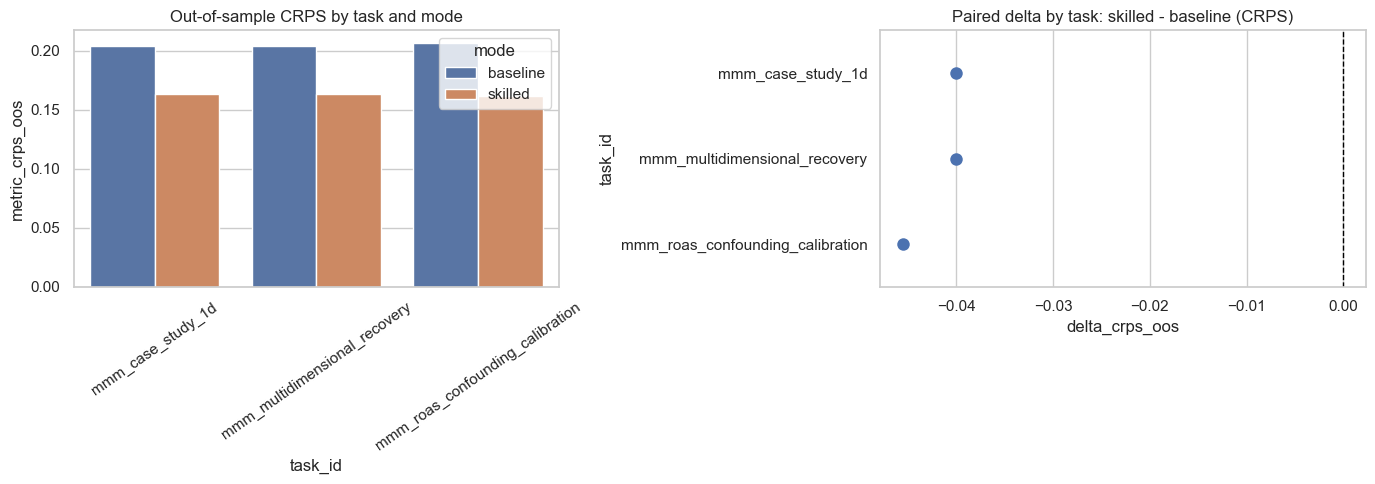

In [2]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=task_df,
    x="task_id",
    y="metric_crps_oos",
    hue="mode",
    ax=axes[0],
)
axes[0].set_title("Out-of-sample CRPS by task and mode")
axes[0].tick_params(axis="x", rotation=35)

if "delta_crps_oos" in paired_df.columns:
    # With very few paired points, a histogram is misleading.
    # Plot per-task deltas directly and include a zero-reference line.
    delta_df = paired_df[["task_id", "delta_crps_oos"]].copy()
    sns.stripplot(
        data=delta_df,
        y="task_id",
        x="delta_crps_oos",
        size=9,
        jitter=False,
        orient="h",
        ax=axes[1],
    )
    axes[1].axvline(0.0, color="black", linestyle="--", linewidth=1)
    axes[1].set_title("Paired delta by task: skilled - baseline (CRPS)")
    axes[1].set_xlabel("delta_crps_oos")
    axes[1].set_ylabel("task_id")
else:
    axes[1].text(0.1, 0.5, "delta_crps_oos not available", fontsize=12)
    axes[1].set_axis_off()

plt.tight_layout()
benchmark_df

,task_id,mode,metric_parameter_recovery_mae,metric_parameter_recovery_rmse,metric_roas_recovery_mae,metric_roas_recovery_rmse,metric_parameter_recovery_shared_key_count
2,mmm_multidimensional_recovery,baseline,0.117921,0.134813,1.019280,1.023131,2.0
3,mmm_multidimensional_recovery,skilled,0.121808,0.137405,1.033807,1.038414,2.0
4,mmm_roas_confounding_calibration,baseline,0.830915,1.118530,131.379193,137.078201,2.0
5,mmm_roas_confounding_calibration,skilled,0.777780,1.086064,131.376982,137.069390,2.0


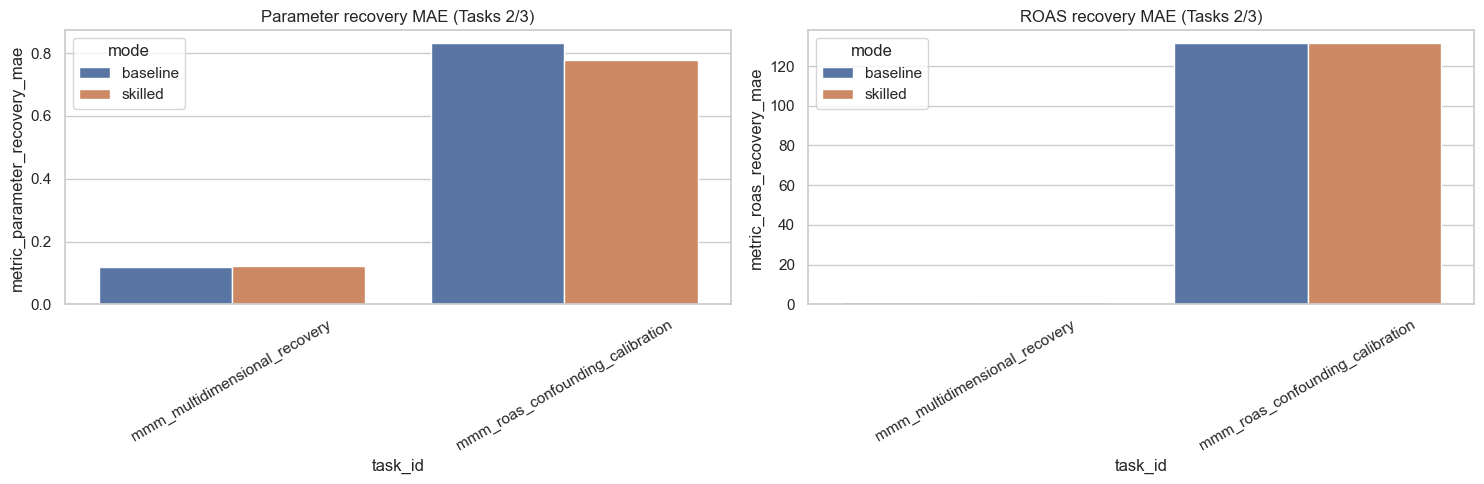

In [3]:
# Parameter recovery deep-dive (Tasks 2 and 3)
import json
from pathlib import Path

recovery_tasks = [
    "mmm_multidimensional_recovery",
    "mmm_roas_confounding_calibration",
]

recovery_df = run_df[run_df["task_id"].isin(recovery_tasks)].copy()

if not recovery_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    sns.barplot(
        data=recovery_df,
        x="task_id",
        y="metric_parameter_recovery_mae",
        hue="mode",
        ax=axes[0],
    )
    axes[0].set_title("Parameter recovery MAE (Tasks 2/3)")
    axes[0].tick_params(axis="x", rotation=30)

    sns.barplot(
        data=recovery_df,
        x="task_id",
        y="metric_roas_recovery_mae",
        hue="mode",
        ax=axes[1],
    )
    axes[1].set_title("ROAS recovery MAE (Tasks 2/3)")
    axes[1].tick_params(axis="x", rotation=30)
    plt.tight_layout()

records = []
for _, row in recovery_df.iterrows():
    artifact_path = Path(row["artifacts_path"])
    detail_path = artifact_path / "parameter_recovery_details.json"
    if not detail_path.exists():
        continue

    with open(detail_path, encoding="utf-8") as f:
        detail = json.load(f)

    errors = detail.get("error_by_key", {})
    if isinstance(errors, dict):
        for key, value in errors.items():
            records.append(
                {
                    "task_id": row["task_id"],
                    "mode": row["mode"],
                    "parameter_key": str(key),
                    "absolute_error": float(value),
                }
            )

error_df = pd.DataFrame(records)
if not error_df.empty:
    top_errors = (
        error_df.sort_values("absolute_error", ascending=False)
        .groupby(["task_id", "mode"], as_index=False)
        .head(8)
    )
    plt.figure(figsize=(12, 5))
    sns.barplot(
        data=top_errors,
        x="parameter_key",
        y="absolute_error",
        hue="mode",
    )
    plt.title("Top per-parameter absolute errors (Tasks 2/3)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

recovery_cols = [
    "task_id",
    "mode",
    "metric_parameter_recovery_mae",
    "metric_parameter_recovery_rmse",
    "metric_roas_recovery_mae",
    "metric_roas_recovery_rmse",
    "metric_parameter_recovery_shared_key_count",
]

available_recovery_cols = [col for col in recovery_cols if col in recovery_df.columns]
recovery_df[available_recovery_cols].sort_values(["task_id", "mode"])

,task_id,delta_crps_oos,delta_parameter_recovery_mae,delta_roas_recovery_mae,delta_cv_param_std_mean,fit_difference_explanation
0,mmm_case_study_1d,-0.040015,NaN,NaN,0.003079,Skilled improves out-of-sample CRPS. Skilled i...
1,mmm_multidimensional_recovery,-0.040015,0.003887,0.014527,0.003079,Skilled improves out-of-sample CRPS. Skilled w...
2,mmm_roas_confounding_calibration,-0.045539,-0.053134,-0.002211,NaN,Skilled improves out-of-sample CRPS. Skilled i...


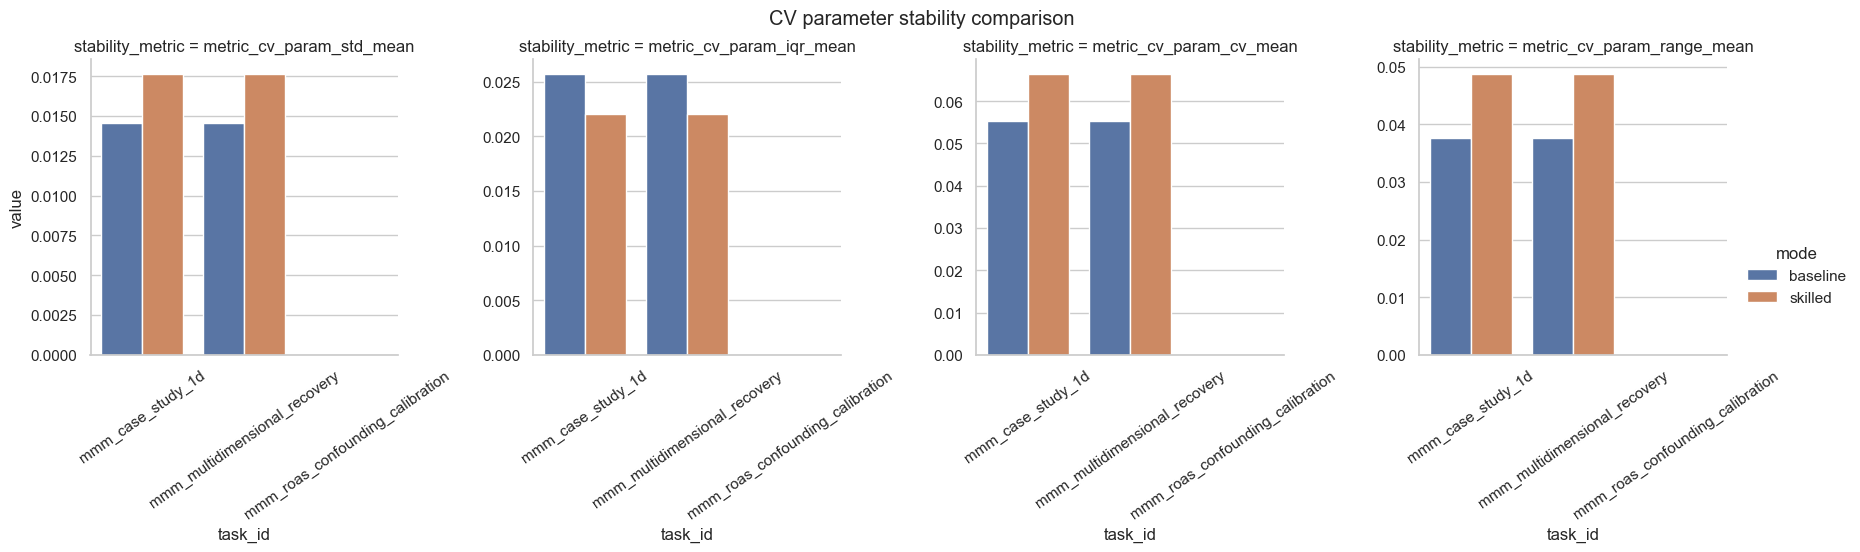

In [4]:
# CV parameter stability + fit-difference decomposition
stability_cols = [
    "metric_cv_param_std_mean",
    "metric_cv_param_iqr_mean",
    "metric_cv_param_cv_mean",
    "metric_cv_param_range_mean",
]

available_stability_cols = [col for col in stability_cols if col in run_df.columns]

if available_stability_cols:
    stability_long = run_df[["task_id", "mode", *available_stability_cols]].melt(
        id_vars=["task_id", "mode"],
        var_name="stability_metric",
        value_name="value",
    )
    g = sns.catplot(
        data=stability_long,
        x="task_id",
        y="value",
        hue="mode",
        col="stability_metric",
        kind="bar",
        sharey=False,
        height=4,
        aspect=1.1,
    )
    g.set_xticklabels(rotation=35)
    g.fig.suptitle("CV parameter stability comparison", y=1.03)


delta_cols = [
    "delta_crps_oos",
    "delta_parameter_recovery_mae",
    "delta_roas_recovery_mae",
    "delta_cv_param_std_mean",
]
available_delta_cols = [col for col in delta_cols if col in paired_df.columns]

fit_delta_df = paired_df[["task_id", *available_delta_cols]].copy()
fit_delta_df.head()


def _explain_row(row: pd.Series) -> str:
    messages = []

    delta_crps = row.get("delta_crps_oos")
    if pd.notna(delta_crps):
        if delta_crps < 0:
            messages.append("Skilled improves out-of-sample CRPS.")
        elif delta_crps > 0:
            messages.append("Skilled worsens out-of-sample CRPS.")

    delta_param = row.get("delta_parameter_recovery_mae")
    if pd.notna(delta_param):
        if delta_param < 0:
            messages.append("Skilled improves parameter recovery.")
        elif delta_param > 0:
            messages.append("Skilled worsens parameter recovery.")

    delta_roas = row.get("delta_roas_recovery_mae")
    if pd.notna(delta_roas):
        if delta_roas < 0:
            messages.append("Skilled improves ROAS recovery.")
        elif delta_roas > 0:
            messages.append("Skilled worsens ROAS recovery.")

    delta_stability = row.get("delta_cv_param_std_mean")
    if pd.notna(delta_stability):
        if delta_stability < 0:
            messages.append("Skilled is more parameter-stable across CV folds.")
        elif delta_stability > 0:
            messages.append("Skilled is less parameter-stable across CV folds.")

    if not messages:
        return "No clear signal (missing delta values)."
    return " ".join(messages)


fit_delta_df["fit_difference_explanation"] = fit_delta_df.apply(_explain_row, axis=1)
fit_delta_df.head()